In [1]:
import torch
import torchaudio
import numpy as np
import matplotlib.pyplot as plt

In [2]:
sample_rate=22050
duration = 3.0
t=torch.linspace(0,duration, int(sample_rate*duration))
waveform=torch.sin(torch.pi*2*440*t)
print(f"sample_rate : {sample_rate} Hz")
print(f"duration    : {duration} seconds")
print(f"total samples: {len(waveform)}")
print(f"waveform shape: {waveform.shape}")
print(f"value range   : [{waveform.min():.3f}, {waveform.max():.3f}]")

sample_rate : 22050 Hz
duration    : 3.0 seconds
total samples: 66150
waveform shape: torch.Size([66150])
value range   : [-1.000, 1.000]


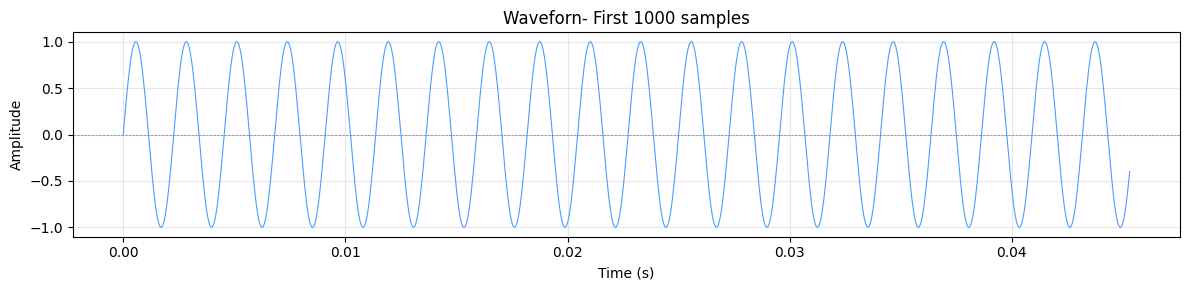

In [3]:
plt.figure(figsize=(12,3))
plt.plot(t[:1000].numpy(), waveform[:1000].numpy(), color="#4a9eff",linewidth=0.8)
plt.title("Waveforn- First 1000 samples")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.axhline(0,color="gray",linewidth=0.5,linestyle="--")
plt.grid(True,alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
n_fft=1024
hop_length=256
win_length=1024
window=torch.hann_window(win_length)
stft=torch.stft(
    waveform,
    n_fft=n_fft,
    hop_length=hop_length,
    win_length=win_length,
    window=window,
    center=True,
    normalized=False,
    onesided=True,
    return_complex=True
)
print(f"STFT output shape: {stft.shape}")
print(f"  dim 0 = frequency bins: {stft.shape[0]}")
print(f"  dim 1 = time frames:    {stft.shape[1]}")
print(f"dtype: {stft.dtype}  (complex — has real + imaginary part)")

STFT output shape: torch.Size([513, 259])
  dim 0 = frequency bins: 513
  dim 1 = time frames:    259
dtype: torch.complex64  (complex — has real + imaginary part)


In [5]:
magnitude=torch.abs(stft)
print(f"Magnitude shape: {magnitude.shape}")
print(f"dtype: {magnitude.dtype}  (real now — no more complex)")
print(f"value range: [{magnitude.min():.4f}, {magnitude.max():.4f}]")

Magnitude shape: torch.Size([513, 259])
dtype: torch.float32  (real now — no more complex)
value range: [0.0000, 7.0751]


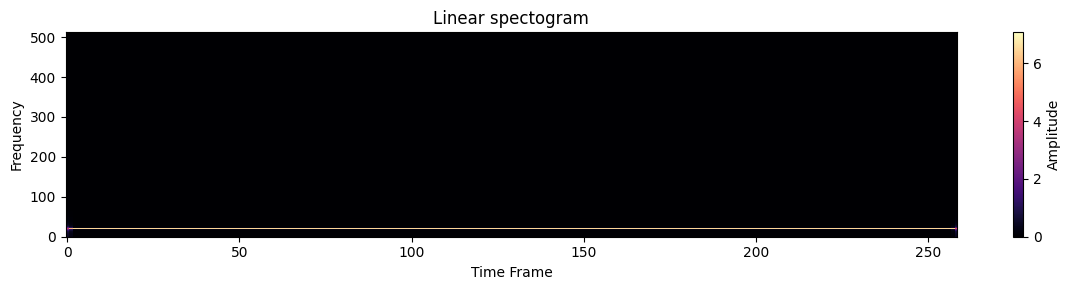

In [6]:
plt.figure(figsize=(12,3))
plt.imshow(
    magnitude.numpy(),
    aspect="auto",
    origin="lower",
    interpolation="none",
    cmap="magma"
)
plt.colorbar(label="Amplitude")
plt.title("Linear spectogram")
plt.xlabel("Time Frame")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [7]:
def hz_to_mel(hz):
    return 2595.0*np.log10(1.0+hz/700.0)
def mel_to_hz(mel):
    return 700*(10.0**(mel/2595.0)-1.0)
n_mels=80
fmin=0.0
fmax=8000.0
mel_min=hz_to_mel(fmin)
mel_max=hz_to_mel(fmax)
mel_points=np.linspace(mel_min,mel_max,n_mels+2)
hz_points=np.array([mel_to_hz(m) for m in mel_points])
print("Mel scale range:")
print(f"  {fmin} Hz  →  mel {mel_min:.1f}")
print(f"  {fmax} Hz  →  mel {mel_max:.1f}")

print("\nFilter center frequencies (Hz) — notice the uneven spacing:")
for i in [0, 1, 2, 10, 20, 40, 60, 78, 79]:
    print(f"  Filter {i:2d}: center = {hz_points[i+1]:8.1f} Hz")

print("\nKey insight:")
print("  Filters 0-10 cover:  0 - 500 Hz   (50 Hz each, very tight)")
print("  Filters 60-79 cover: 4000-8000 Hz (200 Hz each, much wider)")
print("  Same mel step, very different Hz widths — that's the mel scale.")

Mel scale range:
  0.0 Hz  →  mel 0.0
  8000.0 Hz  →  mel 2840.0

Filter center frequencies (Hz) — notice the uneven spacing:
  Filter  0: center =     22.1 Hz
  Filter  1: center =     44.9 Hz
  Filter  2: center =     68.5 Hz
  Filter 10: center =    285.7 Hz
  Filter 20: center =    645.4 Hz
  Filter 40: center =   1806.5 Hz
  Filter 60: center =   3969.7 Hz
  Filter 78: center =   7475.2 Hz
  Filter 79: center =   7733.5 Hz

Key insight:
  Filters 0-10 cover:  0 - 500 Hz   (50 Hz each, very tight)
  Filters 60-79 cover: 4000-8000 Hz (200 Hz each, much wider)
  Same mel step, very different Hz widths — that's the mel scale.


In [8]:
num_freq_bins=n_fft//2 +1
fft_freqs=np.linspace(0, sample_rate/2,num_freq_bins)
bin_indices=np.searchsorted(fft_freqs,hz_points)
print("Mapping filter centres to FFT bin indices: \n")
for i in [0,1,40,79]:
    hz=hz_points[i+1]
    idx=bin_indices[i+1]
    print(f" Filter: {i:2d}: {hz:8.1f} Hz --> FFT Bin {idx}")
filterbank=np.zeros((n_mels, num_freq_bins), dtype=np.float32)
for m in range(1, n_mels+1):
    left=bin_indices[m-1]
    centre=bin_indices[m]
    right=bin_indices[m+1]

    for k in range(left, centre):
        if centre!= left:
            filterbank[m-1,k]=(k-left)/(centre-left)
    for k in range(centre, right):
        if right != centre:
            filterbank[m-1,k]=(right-k)/(right - centre)
filterbank_tensor= torch.FloatTensor(filterbank)
print(f"\nFilterbank shape: {filterbank_tensor.shape}")
print(f"  Each of the 80 rows = one triangular filter")
print(f"  Each of the 513 columns = one FFT frequency bin")
print(f"  Most values are 0.0 — each filter is nonzero only near its center")
print(f"\nNonzero entries in filter 0:  {(filterbank[0] > 0).sum()} bins")
print(f"Nonzero entries in filter 40: {(filterbank[40] > 0).sum()} bins")
print(f"Nonzero entries in filter 79: {(filterbank[79] > 0).sum()} bins")
print("Notice: high-frequency filters span more bins (wider in Hz)")

Mapping filter centres to FFT bin indices: 

 Filter:  0:     22.1 Hz --> FFT Bin 2
 Filter:  1:     44.9 Hz --> FFT Bin 3
 Filter: 40:   1806.5 Hz --> FFT Bin 84
 Filter: 79:   7733.5 Hz --> FFT Bin 360

Filterbank shape: torch.Size([80, 513])
  Each of the 80 rows = one triangular filter
  Each of the 513 columns = one FFT frequency bin
  Most values are 0.0 — each filter is nonzero only near its center

Nonzero entries in filter 0:  2 bins
Nonzero entries in filter 40: 6 bins
Nonzero entries in filter 79: 23 bins
Notice: high-frequency filters span more bins (wider in Hz)


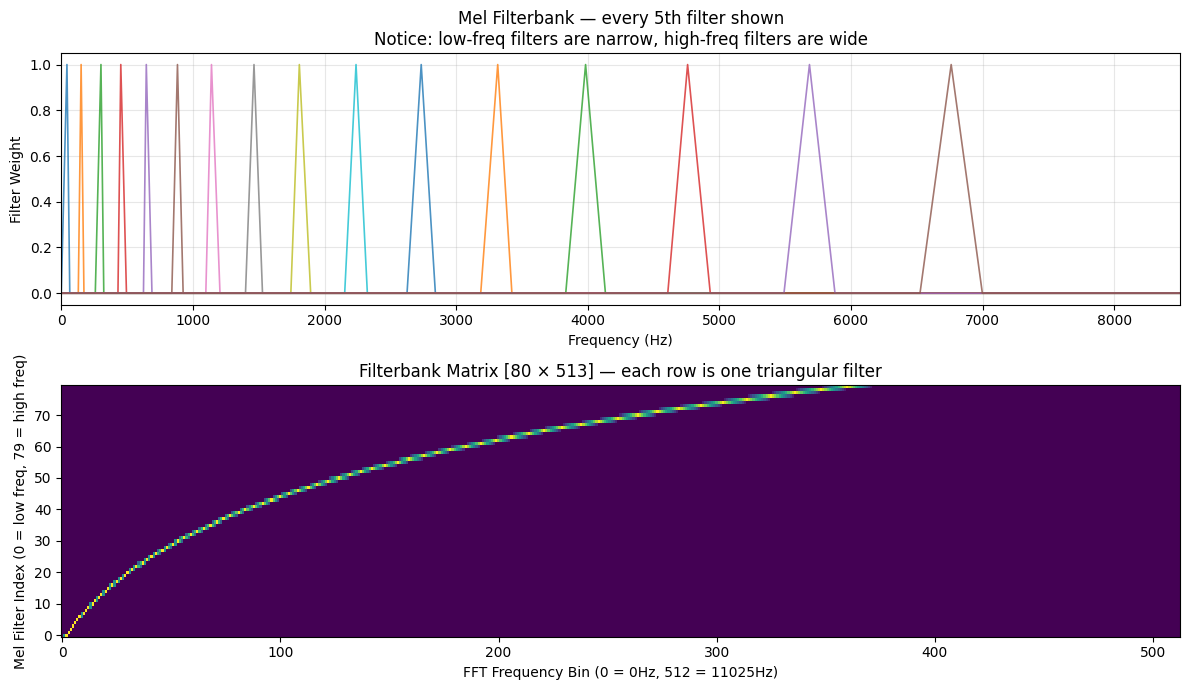

What you're seeing in plot 2:
  Each bright diagonal stripe = one triangular filter
  Stripes get wider as you go right = wider filters at high frequencies
  This is the mel scale made visual


In [9]:
fig, axes=plt.subplots(2,1,figsize=(12,7))
ax=axes[0]
for i in range(0,n_mels,5):
    ax.plot(fft_freqs,filterbank[i],linewidth=1.2,alpha=0.8)
ax.set_title("Mel Filterbank — every 5th filter shown\n"
             "Notice: low-freq filters are narrow, high-freq filters are wide")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Filter Weight")
ax.set_xlim(0, 8500)
ax.grid(True, alpha=0.3)

# ── Plot 2: the filterbank as a heatmap ───────────────────────────────────
# This shows the full [80 × 513] matrix as an image.
# Each row = one filter. Bright = high weight, dark = zero.
# You should see diagonal stripes getting wider toward the right (high freq).
ax = axes[1]
ax.imshow(
    filterbank,
    aspect="auto",
    origin="lower",
    interpolation="none",
    cmap="viridis"
)
ax.set_title("Filterbank Matrix [80 × 513] — each row is one triangular filter")
ax.set_xlabel("FFT Frequency Bin (0 = 0Hz, 512 = 11025Hz)")
ax.set_ylabel("Mel Filter Index (0 = low freq, 79 = high freq)")

plt.tight_layout()
plt.show()

print("What you're seeing in plot 2:")
print("  Each bright diagonal stripe = one triangular filter")
print("  Stripes get wider as you go right = wider filters at high frequencies")
print("  This is the mel scale made visual")

In [10]:
power = magnitude**2
print(f"Power spectrogram shape: {power.shape}  [n_freq_bins × time_frames]")
mel=torch.matmul(filterbank_tensor,power)

print(f"After filterbank:        {mel.shape}   [n_mels × time_frames]")
print(f"\nCompression achieved:")
print(f"  {power.shape[0]} FFT bins → {mel.shape[0]} mel bins")
print(f"  {power.shape[0] / mel.shape[0]:.1f}x reduction in frequency dimension")
print(f"\nMel energy range: [{mel.min():.6f}, {mel.max():.6f}]")
print(f"  (Very wide range — this is why we need log next)")

Power spectrogram shape: torch.Size([513, 259])  [n_freq_bins × time_frames]
After filterbank:        torch.Size([80, 259])   [n_mels × time_frames]

Compression achieved:
  513 FFT bins → 80 mel bins
  6.4x reduction in frequency dimension

Mel energy range: [0.000000, 51.412155]
  (Very wide range — this is why we need log next)


In [11]:
log_epsilon=1e-5
log_mel=torch.log(mel+log_epsilon)
print("Effect of log scaling:")
print(f"  Before: [{mel.min():.8f},  {mel.max():.4f}]")
print(f"  After:  [{log_mel.min():.4f}, {log_mel.max():.4f}]")

print(f"\nWhat specific energy levels become:")
for energy in [0.0, 1e-5, 1e-4, 1e-3, 0.01, 0.1, 1.0, 10.0]:
    print(f"  energy {energy:10.6f}  →  log = {np.log(energy + log_epsilon):7.3f}")

print(f"\nThe neural network sees values in roughly [-12, 3].")
print(f"Its weights (also in that range) can now meaningfully learn from this.")

Effect of log scaling:
  Before: [0.00000000,  51.4122]
  After:  [-11.5129, 3.9399]

What specific energy levels become:
  energy   0.000000  →  log = -11.513
  energy   0.000010  →  log = -10.820
  energy   0.000100  →  log =  -9.115
  energy   0.001000  →  log =  -6.898
  energy   0.010000  →  log =  -4.604
  energy   0.100000  →  log =  -2.302
  energy   1.000000  →  log =   0.000
  energy  10.000000  →  log =   2.303

The neural network sees values in roughly [-12, 3].
Its weights (also in that range) can now meaningfully learn from this.


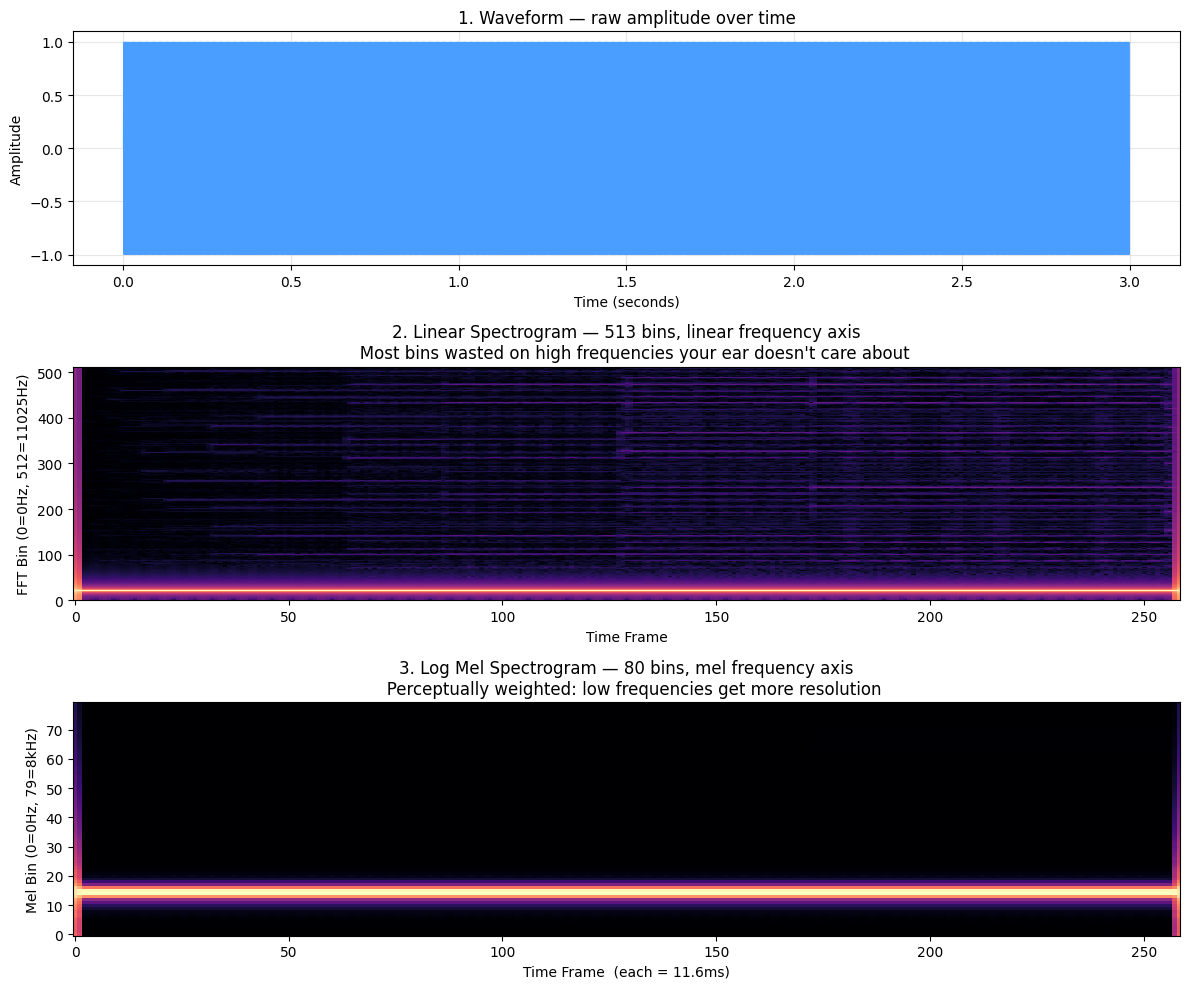


Final output shape: torch.Size([80, 259])  [n_mels × time_frames]
During training this will be: [batch_size, 80, time_frames]
e.g. a batch of 16 clips:     [16, 80, ~200]

This is the format every component of the model uses.
Week 2 will produce TEXT features that pair with this.
The acoustic model maps text → this. The vocoder maps this → audio.


In [12]:
fig, axes=plt.subplots(3,1,figsize=(12,10))
time_axis=np.linspace(0,duration,len(waveform))
axes[0].plot(time_axis, waveform.numpy(), linewidth=0.5, color="#4a9eff")
axes[0].set_title("1. Waveform — raw amplitude over time")
axes[0].set_xlabel("Time (seconds)")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, alpha=0.3)

# ── Plot 2: Linear spectrogram (what we had after Cell 6) ─────────────────
# Using log of the linear spectrogram so colors are visible (otherwise
# the one loud frequency dominates and everything else looks black).
axes[1].imshow(
    torch.log(magnitude + 1e-5).numpy(),
    aspect="auto",
    origin="lower",
    interpolation="none",
    cmap="magma"
)
axes[1].set_title(f"2. Linear Spectrogram — {num_freq_bins} bins, linear frequency axis\n"
                  f"   Most bins wasted on high frequencies your ear doesn't care about")
axes[1].set_xlabel("Time Frame")
axes[1].set_ylabel(f"FFT Bin (0=0Hz, {num_freq_bins-1}=11025Hz)")

# ── Plot 3: Log mel spectrogram (our final output) ─────────────────────────
axes[2].imshow(
    log_mel.numpy(),
    aspect="auto",
    origin="lower",
    interpolation="none",
    cmap="magma"
)
axes[2].set_title(f"3. Log Mel Spectrogram — {n_mels} bins, mel frequency axis\n"
                  f"   Perceptually weighted: low frequencies get more resolution")
axes[2].set_xlabel("Time Frame  (each = 11.6ms)")
axes[2].set_ylabel(f"Mel Bin (0=0Hz, {n_mels-1}=8kHz)")

plt.tight_layout()
plt.show()

print(f"\nFinal output shape: {log_mel.shape}  [n_mels × time_frames]")
print(f"During training this will be: [batch_size, {n_mels}, time_frames]")
print(f"e.g. a batch of 16 clips:     [16, 80, ~200]")
print()
print("This is the format every component of the model uses.")
print("Week 2 will produce TEXT features that pair with this.")
print("The acoustic model maps text → this. The vocoder maps this → audio.")